In [1]:
import torch
import torch.nn as nn
import numpy as np

In [2]:
text = "hello world hello world hello world"

In [3]:
chars = sorted(list(set(text)))
char_to_idx = {ch:i for i,ch in enumerate(chars)}
idx_to_char = {i:ch for ch,i in char_to_idx.items()}

vocab_size = len(chars)

In [4]:
data = [char_to_idx[ch] for ch in text]

In [5]:
seq_len = 5
X = []
Y = []

In [6]:
for i in range(len(data)-seq_len):
    X.append(data[i:i+seq_len])
    Y.append(data[i+1:i+seq_len+1])

In [7]:
X = torch.tensor(X)
Y = torch.tensor(Y)

In [8]:
print("Vocabulary:", chars)
print("X shape:", X.shape)

Vocabulary: [' ', 'd', 'e', 'h', 'l', 'o', 'r', 'w']
X shape: torch.Size([30, 5])


In [9]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, hidden_size)

        self.rnn = nn.RNN(
            input_size=hidden_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):

        x = self.embedding(x)

        out, hidden = self.rnn(x, hidden)

        logits = self.fc(out)

        return logits, hidden, out

model = CharRNN(vocab_size, hidden_size=16)

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(300):

    optimizer.zero_grad()

    logits, _, _ = model(X)

    loss = criterion(
        logits.reshape(-1, vocab_size),
        Y.reshape(-1)
    )

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")

Epoch 0, Loss = 2.1486
Epoch 50, Loss = 0.1757
Epoch 100, Loss = 0.1180
Epoch 150, Loss = 0.1109
Epoch 200, Loss = 0.1080
Epoch 250, Loss = 0.1065


In [11]:
def generate_text(start_text, length=50):

    model.eval()

    chars_generated = list(start_text)

    hidden = None

    for _ in range(length):

        x = torch.tensor(
            [[char_to_idx[ch] for ch in chars_generated[-seq_len:]]]
        )

        logits, hidden, _ = model(x, hidden)

        last_logits = logits[0, -1]

        prob = torch.softmax(last_logits, dim=0)

        next_idx = torch.argmax(prob).item()

        next_char = idx_to_char[next_idx]

        chars_generated.append(next_char)

    return "".join(chars_generated)

print(generate_text("hello"))

hello world hello world hello world hello world hello w


In [12]:
import matplotlib.pyplot as plt

sample = "hello"

x = torch.tensor(
    [[char_to_idx[ch] for ch in sample]]
)

with torch.no_grad():
    _, _, hidden_states = model(x)

hidden_states = hidden_states.squeeze(0).numpy()

print(hidden_states.shape)

(5, 16)


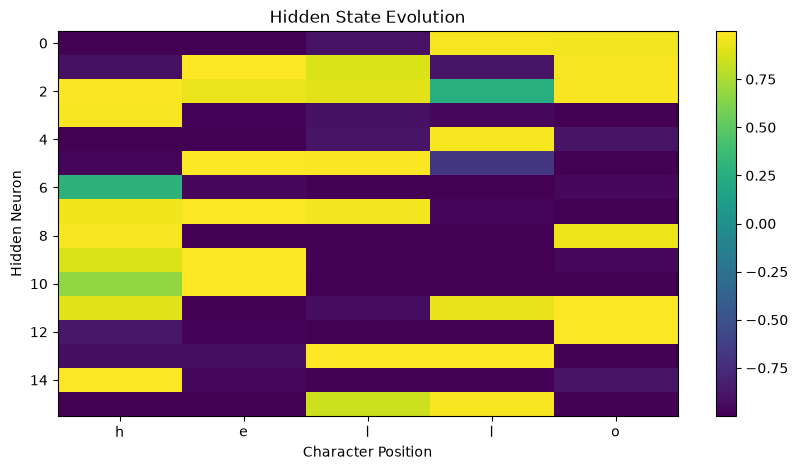

In [13]:
plt.figure(figsize=(10,5))

plt.imshow(
    hidden_states.T,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar()
plt.xlabel("Character Position")
plt.ylabel("Hidden Neuron")
plt.title("Hidden State Evolution")

plt.xticks(
    range(len(sample)),
    list(sample)
)

plt.show()